In [3]:
from openwind.sar_data import preprocess_sar_data
from openwind.sar_wind import derive_sar_wind
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from nansat import Nansat
from pyresample.geometry import SwathDefinition
from pyresample.kd_tree import resample_nearest

In [4]:
resample_nearest?

Signature:
resample_nearest(
    source_geo_def,
    data,
    target_geo_def,
    radius_of_influence,
    epsilon=0,
    fill_value=0,
    reduce_data=True,
    nprocs=1,
    segments=None,
)
Docstring:
Resamples data using kd-tree nearest neighbour approach.

Parameters
----------
source_geo_def : object
    Geometry definition of source
data : numpy array
    1d array of single channel data points or
    (source_size, k) array of k channels of datapoints
target_geo_def : object
    Geometry definition of target
radius_of_influence : float
    Cut off distance in meters
epsilon : float, optional
    Allowed uncertainty in meters. Increasing uncertainty
    reduces execution time
fill_value : int, float, numpy floating, numpy integer or None, optional
        Set undetermined pixels to this value.
        If fill_value is None a masked array is returned
        with undetermined pixels masked
reduce_data : bool, optional
    Perform initial coarse reduction of source dataset in order

In [8]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import xarray as xr
from openwind.gmf.cmod5n import cmod5n_forward
from tqdm import tqdm

In [9]:
ds = xr.open_dataset('S1A_IW_GRDH_1SDV_20200212T004113_20200212T004141_031212_0396DD_43D4.nc')

In [12]:
grdh_geometry = SwathDefinition(lats=ds.lat.data, lons=ds.lon.data)

In [25]:
wind_ds = xr.open_dataset('/src/.devcontainer/S1A_IW_OCN__2SDV_20200212T004113_20200212T004141_031212_0396DD_35D4.SAFE/measurement/s1a-iw-ocn-vv-20200212t003430-20200212t003502-031212-0396DD-001.nc')

In [26]:
wind_ds = wind_ds[['owiLon', 'owiLat', 'owiIncidenceAngle', 'owiEcmwfWindSpeed', 'owiEcmwfWindDirection', 'owiHeading']]

In [27]:
ocn_geometry = SwathDefinition(lats=wind_ds.owiLat.data, lons=wind_ds.owiLon.data)

In [42]:
wind_dir = resample_nearest(ocn_geometry, wind_ds.owiEcmwfWindDirection.data, grdh_geometry, radius_of_influence=2000)
wind_spd = resample_nearest(ocn_geometry, wind_ds.owiEcmwfWindSpeed.data, grdh_geometry, radius_of_influence=2000)

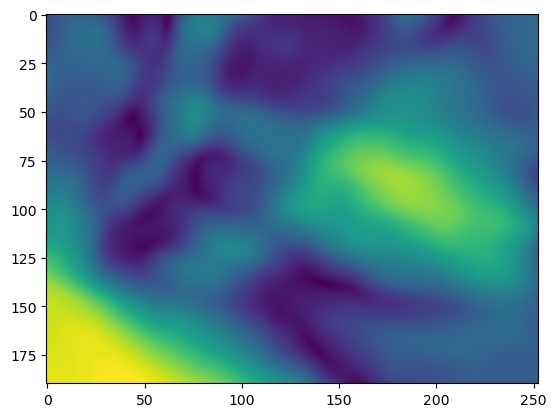

In [30]:
plt.imshow(wind_ds['owiEcmwfWindSpeed'].data)

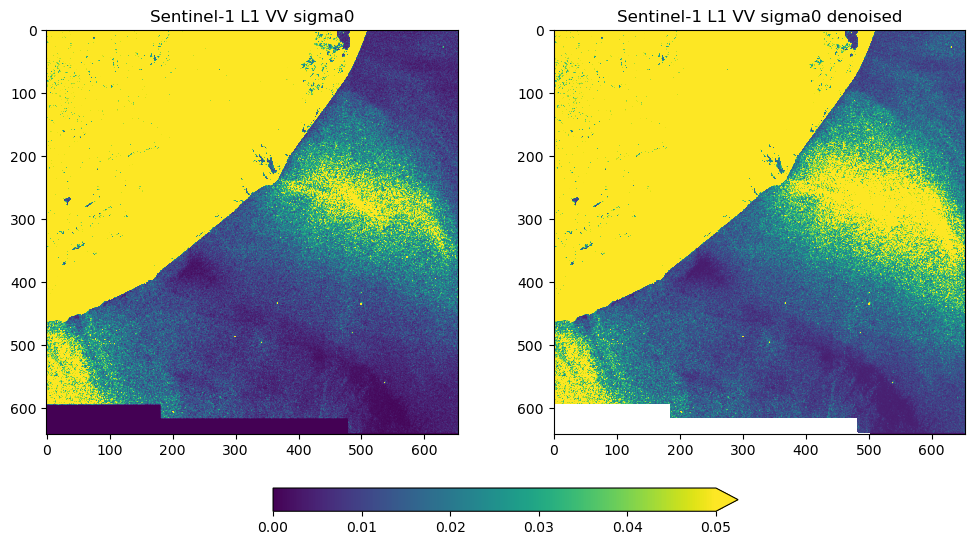

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
ax1.set_title('Sentinel-1 L1 VV sigma0')
im1 = ax1.imshow(ds.sigma0.data[:, 100:-100], clim=(0, 0.05), cmap='viridis')
ax2.set_title('Sentinel-1 L1 VV sigma0 denoised')
im2 = ax2.imshow(ds.sigma0_s1dn.data[:, 100:-100], clim=(0, 0.05), cmap='viridis')

plt.colorbar(im1, ax=[ax1,ax2], orientation='horizontal', shrink=0.5, pad=0.1, extend='max')
plt.show()

In [36]:
def cmod5n_inverse(sigma0_obs, phi, incidence, iterations: int = 10):
    """
    Inverse wind speed from SAR sigma0 and model wind direction.
    This function iterates the forward CMOD5N function until agreement 
    with input (observed) sigma0 values

    :param sigma0_obs: Normalized Radar Cross Section in linear units
    :param phi:        Angle between azimuth and wind direction (phi = D - AZM) in deg.
    :param incidence:  Incidence angle in deg.
    :param iterations: Number of iterations to run

    :returns V:        Wind speed at 10 m height in m/s, neutral stratification
    """    
    # First guess wind speed
    V = np.full(sigma0_obs.shape, 10)
    step = 3
    
    # Iterating until error is smaller than threshold
    for iterno in tqdm(range(1, iterations), total=len(range(1, iterations))):
        sigma0_calc = cmod5n_forward(V, phi, incidence)
        ind = sigma0_calc - sigma0_obs > 0
        V = V + step
        V[ind] = V[ind] - 2*step 
        step = step/2
    return V

In [46]:
phi = np.mod(wind_dir[50:550, 100:-100] - ds.look_direction.data[50:550, 100:-100], 360)
sar_wind_spd = cmod5n_inverse(ds.sigma0.data[50:550, 100:-100], phi, ds.angle_of_incidence.data[50:550, 100:-100], iterations=10,)


100%|██████████| 9/9 [00:00<00:00, 15.49it/s]


In [50]:
phi = np.mod(wind_dir[50:550, 100:-100] - ds.look_direction.data[50:550, 100:-100], 360)
sar_wind_spd_dn = cmod5n_inverse(ds.sigma0_s1dn.data[50:550, 100:-100], phi, ds.angle_of_incidence.data[50:550, 100:-100], iterations=10,)


100%|██████████| 9/9 [00:00<00:00, 15.57it/s]


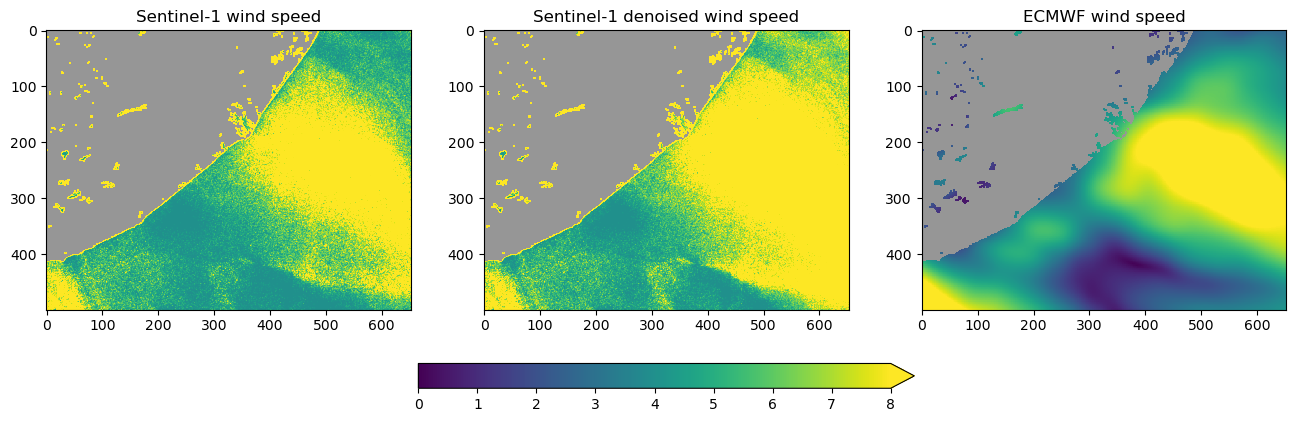

In [53]:
wm = ds.watermask.data[50:550, 100:-100]
wm[wm == 1] = np.nan


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 7))
ax1.set_title('Sentinel-1 wind speed')
im1 = ax1.imshow(sar_wind_spd, clim=(0, 8))
ax1.imshow(wm, cmap='Greys_r', clim=(0, 4))
ax2.set_title('Sentinel-1 denoised wind speed')
im2 = ax2.imshow(sar_wind_spd_dn, clim=(0, 8))
ax2.imshow(wm, cmap='Greys_r', clim=(0, 4))

ax3.set_title('ECMWF wind speed')
im3 = ax3.imshow(wind_spd[50:550, 100:-100], clim=(0, 8))
ax3.imshow(wm, cmap='Greys_r', clim=(0, 4))

plt.colorbar(im1, ax=[ax1,ax2,ax3], orientation='horizontal', shrink=0.4, pad=0.1, extend='max')
plt.show()

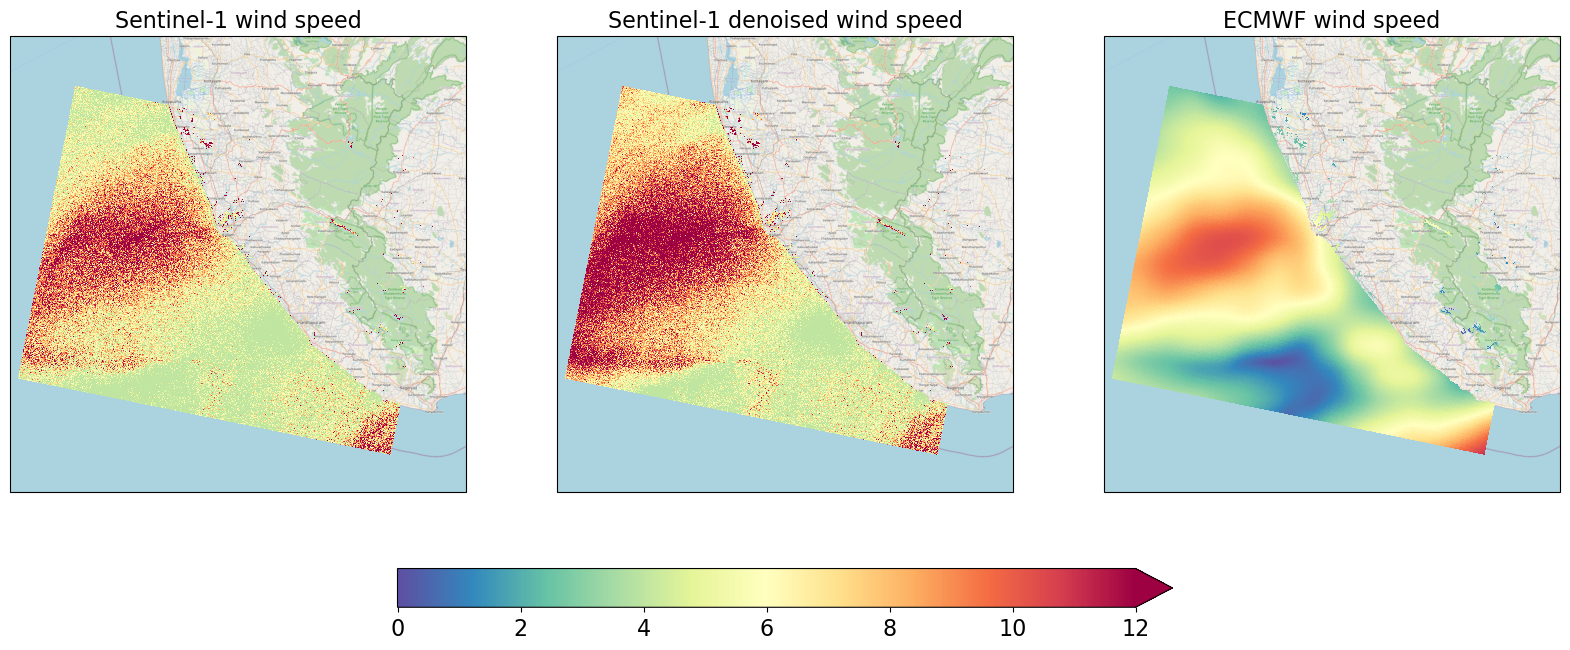

In [117]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature 

request = cimgt.OSM()

fig = plt.figure(figsize=(20, 10))
ax1 = plt.subplot(131, projection=request.crs)
ax1.set_title('Sentinel-1 wind speed', fontsize=16)

wm = ds.watermask.data[50:550, 100:-100]
ws = sar_wind_spd
ws[wm == 2] = np.nan
im1 = ax1.pcolormesh(ds.lon.data[50:550, 100:-100], ds.lat.data[50:550, 100:-100], ws, 
                     clim=(0, 12), zorder=2, transform=ccrs.PlateCarree(), cmap='Spectral_r')

ax2 = plt.subplot(132, projection=request.crs)
ax2.set_title('Sentinel-1 denoised wind speed', fontsize=16)
ws = sar_wind_spd_dn
ws[wm == 2] = np.nan
im2 = ax2.pcolormesh(ds.lon.data[50:550, 100:-100], ds.lat.data[50:550, 100:-100], ws,
                     clim=(0, 12), zorder=2, transform=ccrs.PlateCarree(), cmap='Spectral_r')


ax3 = plt.subplot(133, projection=request.crs)
ax3.set_title('ECMWF wind speed', fontsize=16)

ws = wind_spd[50:550, 100:-100]
ws[wm == 2] = np.nan
im3 = ax3.pcolormesh(ds.lon.data[50:550, 100:-100], ds.lat.data[50:550, 100:-100], ws, 
                     clim=(0, 12), zorder=2, transform=ccrs.PlateCarree(), cmap='Spectral_r')


for ax in [ax1, ax2 ,ax3]:
    # ax.coastlines(color='#666666', linewidth=0.5, zorder=10)
    # ocean_feature = cfeature.NaturalEarthFeature('physical', 'ocean', '10m', edgecolor='face', facecolor='#242424')
    # ax.add_feature(ocean_feature, zorder=1)

    # land_feature = cfeature.NaturalEarthFeature('physical', 'land', '10m', edgecolor='face', facecolor='#404040')
    # ax.add_feature(land_feature, zorder=3)
    # ax.gridlines(ls='--', linewidth=0.5)
    ax.add_image(request, 10)
cb = plt.colorbar(im1, ax=[ax1,ax2,ax3], orientation='horizontal', shrink=0.5, pad=0.1, extend='max')
cb.ax.tick_params(labelsize=16) 
plt.savefig('report.png', dpi=100, bbox_inches = 'tight', pad_inches = 0.1)